<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/labs/cs473_lab_week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 473 Lab Week 3

## Introduction:
In this lab, we'll explore both multivariate Gaussians and mixture models.

Mixture models are a powerful way to combine simple distributions to create complex distributions. Gaussian mixture modeling is a common place to start, because of the attractive theoretical properties of the model.

---
## Exercise #1: Data Generation
First, we'll practice sampling from a mixture model.

In [2]:
import numpy as np

def sample_mm( Mu, Sigma, Weight ):
    # Mu is a list of length k. Each entry in the list is a dx1 vector, representing the mean of the corresponding mixture component
    # Sigma is a list of length k. Each entry is a dxd matrix, representing the corresponding covariance matrix
    # Weight is a list of length k. Each entry is a 1x1 scalar, representing the prior probability of that component
    #
    # Your code should return a single sample from the mixture. It should be a dx1 vector.

    # NOTE: the only sampling functions you can use are np.random.randn and np.random.choice (don't use np.random.multivariate_normal)
    # you can use other math functions as needed
    # HINT: Look at section 7.6.3 of the book for a way to sample from a Multivariate Gaussian

    # your code here

    # Selecct the mixture component, then extract its mean and variance.
    comp = np.random.choice(len(Mu), p=Weight)
    mu = Mu[comp]
    sigma = Sigma[comp]

    # Define single variables (of which there are, sadly, many).
    d = mu.shape[0]
    z = np.random.randn(d, 1)
    L = np.linalg.cholesky(sigma)       # Surely there's an easier way, right?
    x = mu + L @ z

    return x

In [3]:
# our mixture model

mu_1 = np.array([[0.22], [0.45]])
mu_2 = np.array([[0.5], [0.5]])
mu_3 = np.array([[0.77], [0.55]])
Mu = np.array([mu_1, mu_2, mu_3])

Sigma1 = np.array([[0.011, -0.01], [-0.01, 0.018]])
Sigma2 = np.array([[0.018, 0.01], [0.01, 0.011]])
Sigma3 = Sigma1
Sigma = np.array([Sigma1, Sigma2, Sigma3])

### Now, visualize the results and compare to the expected shapes
Here is some simple code for visualizing the level sets of a Gaussian

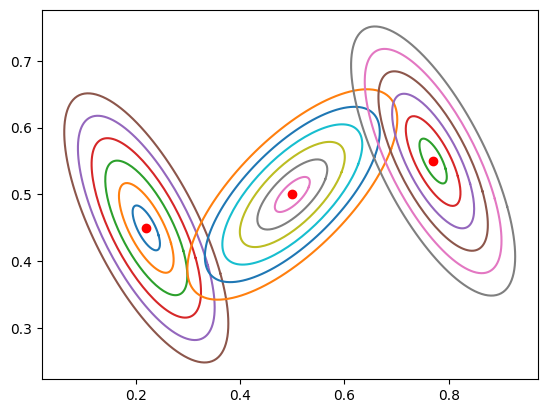

In [4]:
import matplotlib.pyplot as plt
from scipy import linalg
import seaborn as sns

def sigmaEllipse2D(mu, Sigma, level=3, npoints=128):
    """
    SIGMAELLIPSE2D generates x,y-points which lie on the ellipse describing
    a sigma level in the Gaussian density defined by mean and covariance.

    Input:
        MU          [2 x 1] Mean of the Gaussian density
        SIGMA       [2 x 2] Covariance matrix of the Gaussian density
        LEVEL       Which sigma level curve to plot. Can take any positive value,
                    but common choices are 1, 2 or 3. Default = 3.
        NPOINTS     Number of points on the ellipse to generate. Default = 32.

    Output:
        XY          [2 x npoints] matrix. First row holds x-coordinates, second
                    row holds the y-coordinates. First and last columns should
                    be the same point, to create a closed curve.
    """
    phi = np.linspace(0, 2 * np.pi, npoints)
    x = np.cos(phi)
    y = np.sin(phi)
    z = level * np.vstack((x, y))
    xy = mu + linalg.sqrtm(Sigma).dot(z)
    return xy

def plot_sigma_levels(mu, P):
    xy_1 = sigmaEllipse2D(mu, P, 0.25)
    xy_2 = sigmaEllipse2D(mu, P, 0.5)
    xy_3 = sigmaEllipse2D(mu, P, 0.75)
    xy_4 = sigmaEllipse2D(mu, P, 1)
    xy_5 = sigmaEllipse2D(mu, P, 1.25)
    xy_6 = sigmaEllipse2D(mu, P, 1.5)
    plt.plot(xy_1[0], xy_1[1])
    plt.plot(xy_2[0], xy_2[1])
    plt.plot(xy_3[0], xy_3[1])
    plt.plot(xy_4[0], xy_4[1])
    plt.plot(xy_5[0], xy_5[1])
    plt.plot(xy_6[0], xy_6[1])
    plt.plot(mu[0], mu[1], "ro")


for i in range( len(Mu) ):
    plot_sigma_levels(Mu[i], Sigma[i])

# **ASK TA FOR HELP (COMMENT)**
# **FIX**

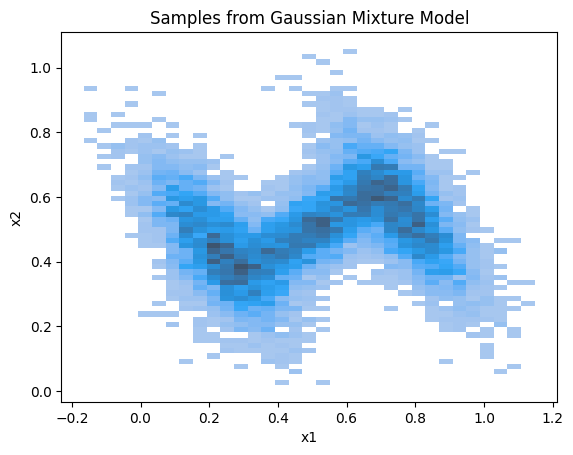

In [5]:
# sample data

# ------------------------------------------------------------------------------
Weight = np.array([1/3, 1/3, 1/3])
# ------------------------------------------------------------------------------

N = 10000
results = [ sample_mm( Mu, Sigma, Weight ) for _ in range(N) ]

#
# create a visualization of the data generated.  (perhaps something like sns.histplot?) Compare it to the level set plots in the previous cell. Do they match?
#
# Correct dimension to avoid ValueError.
res = np.array(results).squeeze()

# Generate (then show) data visualization.
sns.histplot(x=res[:, 0], y=res[:, 1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Samples from Gaussian Mixture Model')

plt.show()

---
## Exercise #2: Marginals
One way to sample from a marginal distribution is to sample from a joint distribution, and throw away the variables that have been marginalized out.  We're going to compare empirical and exact distributions.

You should perform the following:

* Sample from a multivariate Gaussian p(x,y) with the given parameters
* For each sample, throw away the second number (the "y" coordinate)
* Plot the resulting distribution of datapoints

Then, use the equations in the book to calculate the exact density of the marginal distribution over the first dimension (the "x" variable)


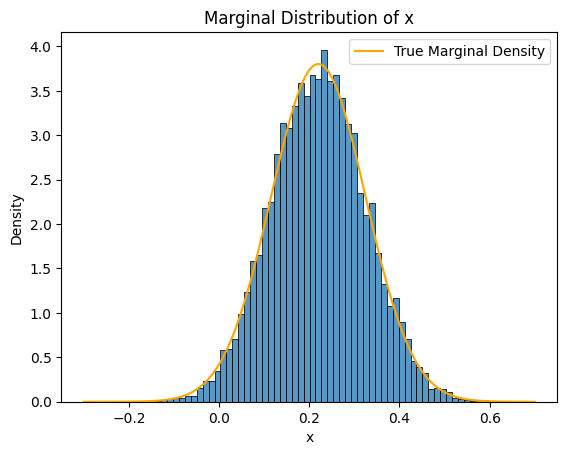

In [6]:
# Use these parameters
mu = np.array([[0.22], [0.45]])
sigma = np.array([[0.011, -0.01], [-0.01, 0.018]])

# YOUR CODE HERE

# Sample
num_samples = 10_000
samples = []
d = mu.shape[0]
L = np.linalg.cholesky(sigma)       # Surely there's an easier way, right?

for _ in range(num_samples):
    z = np.random.randn(d, 1)
    x = mu + L @ z
    samples.append(x)

# Plot the empirical distribution of points (using, for example, a histogram plotting function)
samples = np.array(samples).squeeze()       # This helps with plotting (below).
x_samples = samples[:, 0]
sns.histplot(x=x_samples, bins=60, stat='density')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Marginal Distribution of x')


# Plot the true density curve
mu_x = mu[0, 0]
var_x = sigma[0, 0]
x_vals = np.linspace(-0.3, 0.7, 117)
density = 1 / np.sqrt(2*np.pi * var_x) * np.exp(-(x_vals - mu_x)**2 / (2*var_x))
plt.plot(x_vals, density, color='orange', label='True Marginal Density')
plt.legend()

plt.show()

Now, calculate the density of several points using the marginal distribution over the "y" variable:

* Calculate p(y=0.39)
* Calculate p(y=0.2)

In [7]:
# YOUR CODE HERE

# Extract helpful variables from previous cell.
mu_y = mu[1, 0]
var_y = sigma[1, 1]
y_val = 0.39
density_y = 1 / np.sqrt(2*np.pi * var_y) * np.exp(-(y_val - mu_y)**2 / (2*var_y))

print(f'p(y=0.39) = {density_y}.')

y_val = 0.20
density_y = 1 / np.sqrt(2*np.pi * var_y) * np.exp(-(y_val - mu_y)**2 / (2*var_y))
print(f'p(y=0.20) = {density_y}.')

p(y=0.39) = 2.69057043119227.
p(y=0.20) = 0.523950594834689.


---
## Exercise #3: Conditionals
Now, let's explore the difference between marginals and conditionals.

Use the following joint distribution over 4 variables:

In [8]:
import seaborn as sns

df = sns.load_dataset("penguins")

data = np.array( df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']])
data = data[~np.isnan(data).any(axis=1)] # drop any row with a NaN
data[:,2] /= 200 # scale some stuff
data[:,3] /= 3000

mu = np.mean( data, axis=0 )
sigma = np.cov( data.T )

In [9]:
print(mu)
print(sigma)

[43.92192982 17.15116959  1.00457602  1.4005848 ]
[[ 2.98070543e+01 -2.53423394e+00  2.51878826e-01  8.68530637e-01]
 [-2.53423394e+00  3.89980801e+00 -8.10647519e-02 -2.49123364e-01]
 [ 2.51878826e-01 -8.10647519e-02  4.94329479e-03  1.63740268e-02]
 [ 8.68530637e-01 -2.49123364e-01  1.63740268e-02  7.14590086e-02]]


We'll assume that we have a multivariate normal distribution over 4 variables: p(x1,x2,x3,x4) = N( mu, sigma )

Now, we want to compute the mean of various conditionals

In [10]:
# Compute the parameters of p(x2,x3)  (a marginal)

marg_mu_x2_x3 = mu[1:3];
marg_sigma_x2_x3 = sigma[1:3, 1:3];

print( marg_mu_x2_x3 )
print( marg_sigma_x2_x3 )

[17.15116959  1.00457602]
[[ 3.89980801 -0.08106475]
 [-0.08106475  0.00494329]]


In [11]:
# Compute the parameters or p(x2,x3|x1=34,x4=1.2)

# Split the variables we condition over.
A = [1, 2]
B = [0, 3]
b = np.array([34, 1.2])

mu_A = mu[A]
mu_B = mu[B]

# This sets up Eq. (3.28) in our textbook.
sigma_AA = sigma[np.ix_(A, A)]
sigma_AB = sigma[np.ix_(A, B)]
sigma_BA = sigma[np.ix_(B, A)]
sigma_BB = sigma[np.ix_(B, B)]

# This actually is Eq. (3.28).
cond_mu_x2_x3 = mu_A + sigma_AB @ np.linalg.inv(sigma_BB) @ (b - mu_B)
cond_sigma_x2_x3 = sigma_AA - sigma_AB @ np.linalg.inv(sigma_BB) @ sigma_BA

print( cond_mu_x2_x3 )
print( cond_sigma_x2_x3 )

[17.65853443  0.93806238]
[[ 3.01864381e+00 -2.53366277e-02]
 [-2.53366277e-02  1.04619779e-03]]


In [13]:
# Finally, calculate the density of a specific point:
# First, I'm more familiar with SciPy, so let's import it.
from scipy.stats import multivariate_normal

# calculate p(x2=16, x3=0.99)
point = np.array([16, 0.99])
marg_prob = multivariate_normal.pdf(point, mean=marg_mu_x2_x3, cov=marg_sigma_x2_x3)



print(f'p(x2=16, x3=0.99) = {marg_prob}.')

# calculate p(x2=16, x3=0.99 | x1=34,x4=1.2)
cond_prob = multivariate_normal.pdf(point, mean=cond_mu_x2_x3, cov=cond_sigma_x2_x3)


print(f'p(x2=16, x3=0.99 | x1=34, x4=1.2) = {cond_prob}.')

p(x2=16, x3=0.99) = 0.9488708250114909.
p(x2=16, x3=0.99 | x1=34, x4=1.2) = 0.8453975130964.
